Okay here's the workflow for this:

1. we're iterating over `big_data` which is constructed within the R project
2. for each instance, we'll go to the wav/textgrid pair and:
    - grab the wav file as an array
    - use the `t` variable from `big_data` to query the textgrid & splice the array to the section we need
        - ideally, we select the fifth timepoint here
3. once we have the right section, we perform scipy.signal.welch to estimate the power spectral density 
    - (possibly log-transform that cuz of dB)
4. calculate three reference frequencies:
    - refLower = F1 - B_1/2
    - refMid:
        - If F3 - B_3/2 is greater than F2 + B_2/2, then we'll just use F3 - B_3/2
        - Otherwise, if the formants overlap, I think we're okay just grabbing the point between them both
    - refHigh = 6000 Hz (we're not measuring F4-6 so this is the best we've got.)

In [7]:
import pandas as pd
from quality_ratio_helpers import *
from scipy.signal import welch
import matplotlib.pyplot as plt

all_data = pd.read_csv("praatsauce_output_4-10_7.tsv", sep = "\t")
refHigher = 5500

In [8]:
test_wav = all_data.sample(random_state = 222222222)
# test_wav = all_data.sample()

In [9]:
filename = str(test_wav.file.item())
label = str(test_wav.label.item())
time = float(test_wav.t.item())

samplerate, wav = readInFile(filename, label, time)

<function matplotlib.pyplot.show(close=None, block=None)>

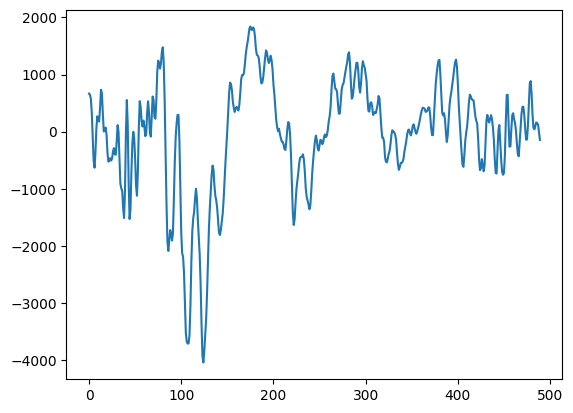

In [10]:
# check out the waveform! :D
plt.plot(wav)
plt.show

In [11]:
# calculate reference frequencies
refLower = calculateLowerReference(float(test_wav.F1.item()), float(test_wav.B1.item()))
refMid = calculateMiddleReference(float(test_wav.F2.item()), float(test_wav.B2.item()), float(test_wav.F3.item()), float(test_wav.B3.item()))

In [12]:
QR = calculateQR(welch(wav, fs = samplerate), (refLower, refMid, refHigher))
QR

np.float64(1.1756949745249847)

In [13]:
# at the end of it all we'll do something like df['QR'] = QR_list